# Этап 1: Исследовательский анализ данных (EDA) и Предобработка

**Цель:** Изучить структуру сырых данных, выявить аномалии и подготовить качественную выборку для обучения.

## 1. Описание датасета
В качестве исходных данных используется открытый датасет детекции средств индивидуальной защиты (СИЗ) со строительных площадок с Kaggle.
* **Формат разметки:** YOLO (нормализованные координаты `x_center, y_center, width, height`)
* **Ожидаемые классы:** `0: helmet`, `1: vest`, `2: head`, `3: person` (как заявлено в исходных файлах).

In [1]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import Counter
import random

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

print("[INFO] Библиотеки загружены")

[INFO] Библиотеки успешно загружены!


## 2. Анализ сырых данных (Raw Data)
Проведем сканирование папки `raw` (которая содержит более 22 000 изображений), чтобы понять реальное распределение классов. Часто датасеты из открытых источников страдают от сильного дисбаланса (Class Imbalance).

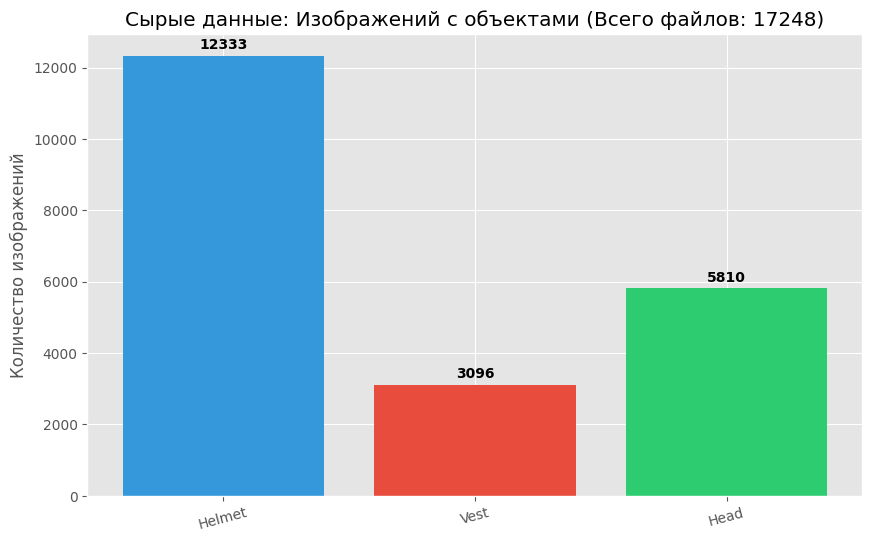

[ВЫВОД] Мы видим дисбаланс на уровне самих фотографий + отсутствие заявленного класса person.


In [14]:
raw_labels_path = r"C:\Practicum\data\raw\labels\train"
raw_files = glob.glob(os.path.join(raw_labels_path, "*.txt"))

raw_img_counts = Counter()

for file in raw_files:
    if "classes" in file: continue
    classes_in_file = set()
    with open(file, 'r') as f:
        for line in f.readlines():
            try:
                cls_id = int(line.split()[0])
                classes_in_file.add(cls_id)
            except: pass

    for c in classes_in_file:
        raw_img_counts[c] += 1

class_names = {0: 'Helmet', 1: 'Vest', 2: 'Head', 3: 'Person'}
names = [class_names.get(i, f"Class {i}") for i in raw_img_counts.keys()]
values = list(raw_img_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(names, values, color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title(f"Сырые данные: Изображений с объектами (Всего файлов: {len(raw_files)})")
plt.ylabel("Количество изображений")
plt.xticks(rotation=15)

for i, v in enumerate(values):
    plt.text(i, v + 200, str(v), ha='center', fontweight='bold')

plt.show()

print(f"[ВЫВОД] Мы видим дисбаланс на уровне самих фотографий + отсутствие заявленного класса person.")

## 3. Балансировка и Очистка (Data Cleaning & Undersampling)
Обучение на сырых данных приведет к смещению (bias) модели: она научится предсказывать мажоритарный класс (каски), но будет игнорировать нарушителей (головы без касок и отсутствие жилетов).

**Принятые архитектурные решения:**
1. Класс `person` исключен из обучения (будет использован сторонний детектор COCO).
2. Применен метод **Undersampling**: количество изображений с касками случайно урезано до уровня миноритарного класса (жилеты).
3. Битые файлы (разметка без картинки) удалены из выборки.

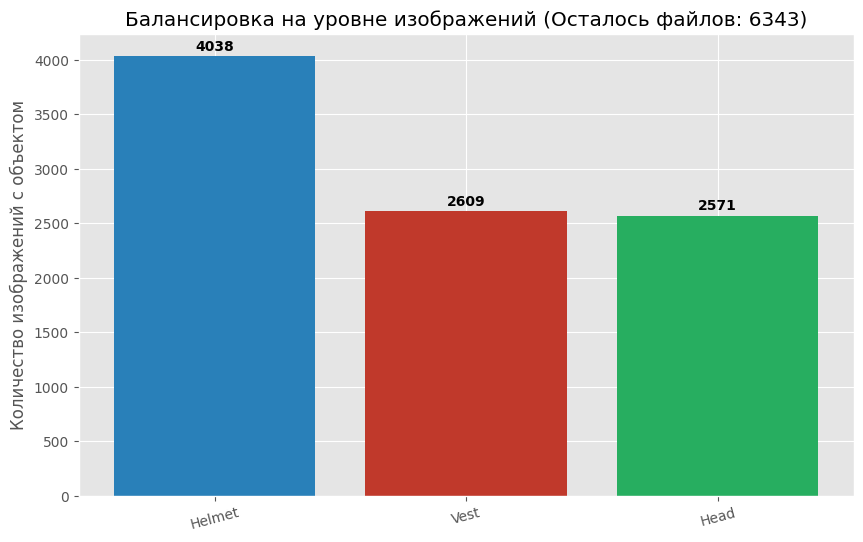

[ВЫВОД] Балансировка на уровне изображений прошла успешно.


In [12]:
processed_labels_path = r"C:\Practicum\data\processed\labels\train"
processed_files = glob.glob(os.path.join(processed_labels_path, "*.txt"))

img_counts = Counter()

for file in processed_files:
    classes_in_file = set()
    with open(file, 'r') as f:
        for line in f.readlines():
            try:
                cls_id = int(line.split()[0])
                classes_in_file.add(cls_id)
            except: pass

    for c in classes_in_file:
        img_counts[c] += 1

proc_names = [class_names.get(i, f"Class {i}") for i in img_counts.keys()]
proc_values = list(img_counts.values())

plt.bar(proc_names, proc_values, color=['#2980b9', '#c0392b', '#27ae60'])
plt.title(f"Балансировка на уровне изображений (Осталось файлов: {len(processed_files)})")
plt.ylabel("Количество изображений с объектом")
plt.xticks(rotation=15)

for i, v in enumerate(proc_values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.show()

print("[ВЫВОД] Балансировка на уровне изображений прошла успешно.")

## 4. Визуализация разметки (Ground Truth Validation)
Перед обучением моделей необходимо визуально убедиться, что координаты YOLO парсятся корректно, а данные в папке `processed` соответствуют реальности.

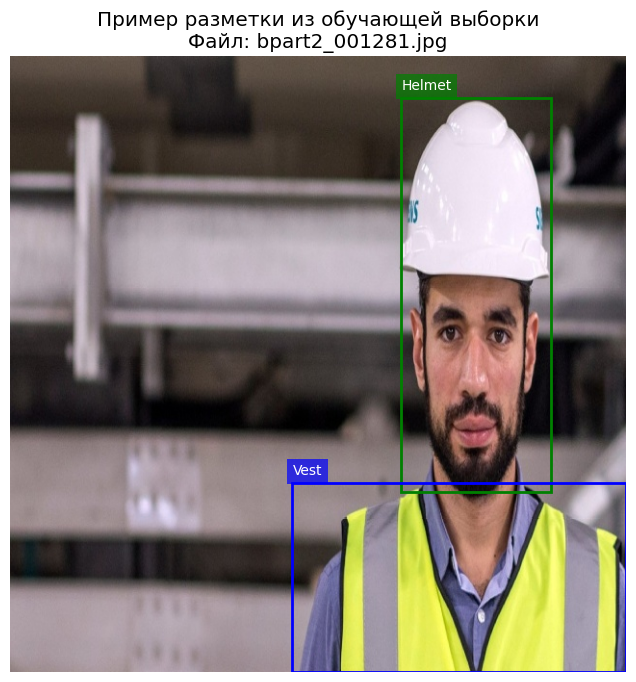

In [13]:
img_dir = r"C:\Practicum\data\processed\images\train"
lbl_dir = r"C:\Practicum\data\processed\labels\train"

img_files = glob.glob(os.path.join(img_dir, "*.jpg"))
sample_img = random.choice(img_files)
sample_lbl = os.path.join(lbl_dir, os.path.basename(sample_img).replace(".jpg", ".txt"))

img = cv2.imread(sample_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape

fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(img)

colors = {0: "green", 1: "blue", 2: "red"}

if os.path.exists(sample_lbl):
    with open(sample_lbl, "r") as f:
        for line in f:
            parts = line.strip().split()
            cls_id = int(parts[0])
            if cls_id in class_names:
                xc, yc, bw, bh = map(float, parts[1:5])

                xmin = (xc - bw/2) * w
                ymin = (yc - bh/2) * h
                box_w = bw * w
                box_h = bh * h

                rect = patches.Rectangle((xmin, ymin), box_w, box_h, linewidth=2, edgecolor=colors[cls_id], facecolor='none')
                ax.add_patch(rect)

                plt.text(xmin, ymin-8, class_names[cls_id], color='white', fontsize=10,
                         bbox=dict(facecolor=colors[cls_id], alpha=0.7, edgecolor='none'))

plt.axis('off')
plt.title(f"Пример разметки из обучающей выборки\nФайл: {os.path.basename(sample_img)}")
plt.show()